In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm, utils, theory, pickle, os, data
from tabulate import tabulate

%load_ext autoreload
%autoreload 2

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1


local_path = '/Users/haozheshan/Dropbox/codes/gp_continual_learning/cluster_results'

class ClusterResultOrganizer:
    def __init__(self, local_path, batch_name):
        self.max_ind = 50
        self.all_data_obj = []
        self.all_args = []
        self.local_path = local_path
        self.batch_name = batch_name
        self.args = None


    def load_all(self):
        for file_ind in range(self.max_ind):
            file_path = f'{self.local_path}/{self.batch_name}/{self.batch_name}_{file_ind}.results'
            if os.path.isfile(file_path):
                _obj = pickle.load(open(file_path, 'rb'))
                self.all_data_obj.append(_obj)
                self.all_args.append(_obj['args'])
                self.args = _obj['args']
        print(f'{len(self.all_data_obj)} data objects loaded.')


    def organize_results(self, value_key, args_key):
        organized_results = {}


        for obj_ind in range(len(self.all_data_obj)):
            if args_key not in vars(self.all_args[obj_ind]).keys():
                raise ValueError('args key not found in results')

            param_name = str(vars(self.all_args[obj_ind])[args_key])

            if value_key not in self.all_data_obj[obj_ind].keys():
                print(f'data with key {value_key} is not found')
                return None
            if param_name in organized_results.keys():
                organized_results[param_name].append(self.all_data_obj[obj_ind][value_key])
            else:
                organized_results[param_name] = [self.all_data_obj[obj_ind][value_key]]

        for param_name in organized_results.keys():
            organized_results[param_name] = np.array(organized_results[param_name])
        return organized_results


organizer = ClusterResultOrganizer(local_path, batch_name='30tasks_TS1_R0_D0_1L_fW0_1cycles')
organizer.load_all()
all_test_loss = organizer.organize_results('test loss', 'P')
all_train_loss = organizer.organize_results('train loss', 'P')
all_test_var = organizer.organize_results('test var', 'P')
all_train_var = organizer.organize_results('train var', 'P')
all_last_loss = organizer.organize_results('last task test', 'P')
lamb_values = 10 ** np.linspace(0, 5, 30)

def check_consistency(args1, args2):
    for key in ['n_tasks', 'P', 'dataset']:
        if vars(args1)[key] != vars(args2)[key]:
            print(f'key "{key}" appears inconsistent between args.')

# check_consistency(organizer.args, batch_organizer.args)
title_text = f' {organizer.args.n_tasks} tasks, teacher speed {organizer.args.teacher_speed},' \
             f' rotation:R{organizer.args.rotation},D{organizer.args.dist}'

title_text += f' net:{organizer.args.depth} layers'
title_text += f'\n fixed w:{bool(organizer.args.fixed_w)}'

10 data objects loaded.


In [2]:
organizer.args

Namespace(f=None, cluster=0, BATCH_NAME='30tasks_TS1_R0_D0_1L_fW0_1cycles', TRIAL_IND=9, P=500, P_test=500, n_tasks=30, N0=1000, T=0.0, sigma=0.2, depth=1, seed=9, fixed_w=0, rotation=0.0, dist=0.0, teacher_speed=1.0, cycles=1)

In [68]:
normalized_test_loss = all_test_loss['500'].copy()
for seed_ind in range(normalized_test_loss.shape[0]):
    for lamb_val_ind in range(normalized_test_loss.shape[1]):
        for time_ind in range(normalized_test_loss.shape[2]):
            normalized_test_loss[seed_ind, lamb_val_ind, :, time_ind] /=\
                all_test_loss['500'][seed_ind, 0, time_ind, time_ind]
mean_normed_test_loss = normalized_test_loss.mean(0)


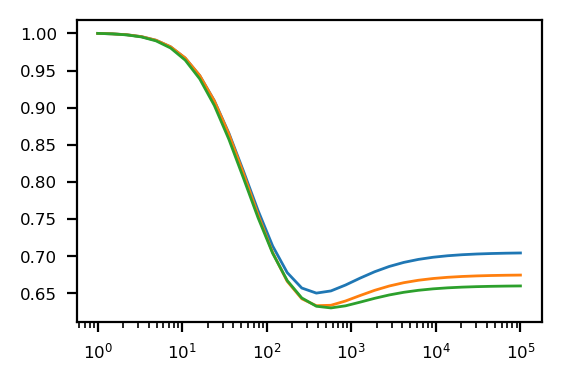

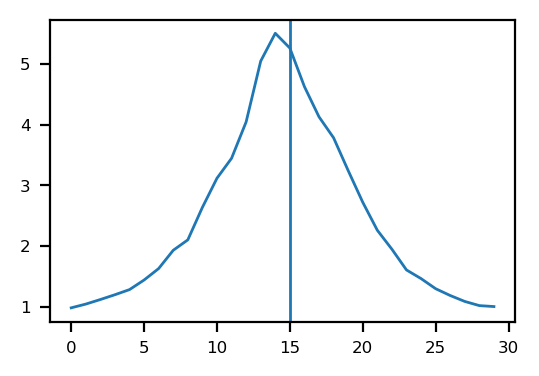

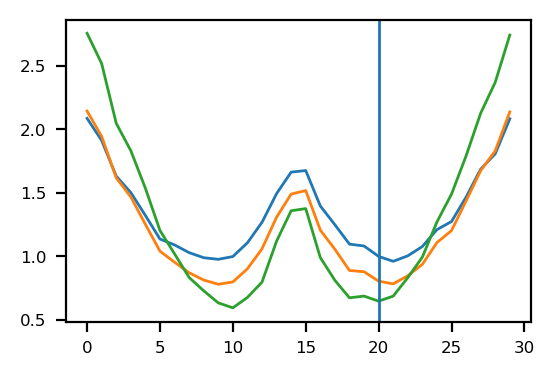

In [71]:
plt.figure()
plt.plot(lamb_values, mean_normed_test_loss[:, -1, -1])
plt.plot(lamb_values, mean_normed_test_loss[:, 10, 10])
plt.plot(lamb_values, mean_normed_test_loss[:, 20, 20])
plt.xscale('log')


plt.figure()
plt.plot(mean_normed_test_loss[0, :, -1])
# plt.plot(mean_normed_test_loss[10, :, 15])
# plt.plot(mean_normed_test_loss[20, :, 15])
# plt.plot(mean_normed_test_loss[-1, :, 15])
plt.axvline(15)


plt.figure()
plt.plot(mean_normed_test_loss[0, :, 20])
plt.plot(mean_normed_test_loss[10, :, 20])
plt.plot(mean_normed_test_loss[20, :, 20])
plt.axvline(20)



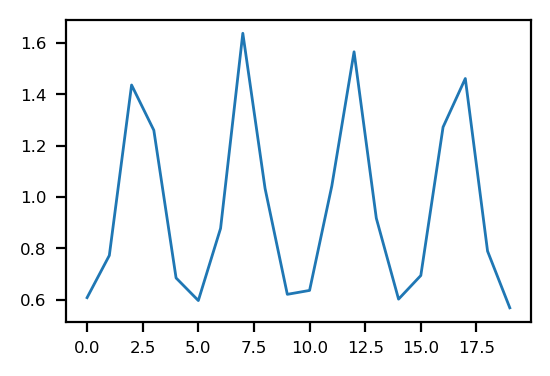

In [9]:
plt.figure()
plt.plot(test_loss.mean(0)[0])

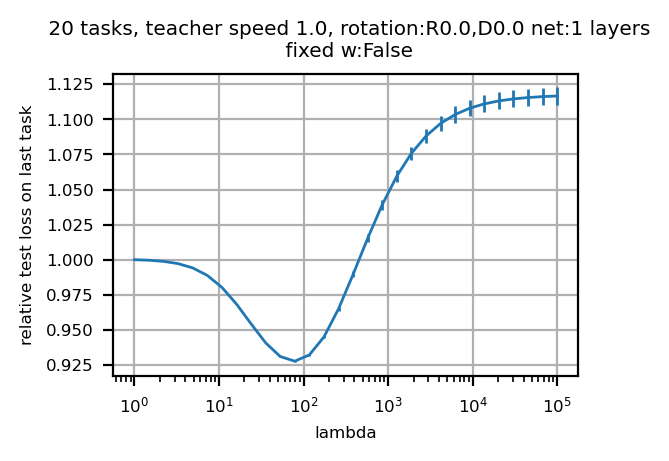

In [2]:
key = '500'

relative_loss = np.zeros_like(all_test_loss[key])
for i in range(len(all_test_loss[key])):
    for j in range(all_test_loss[key].shape[2]):
        relative_loss[i, :, j] = all_test_loss[key][i, :, j] / all_test_loss[key][i, 0, j]

relative_loss_on_last_task = relative_loss[:, :, -1]


plt.figure()
lamb_values = 10 ** np.linspace(0, 5, 30)
plt.errorbar(lamb_values, relative_loss_on_last_task.mean(0), relative_loss_on_last_task.var(0), label=key)
plt.xscale('log')
plt.grid()
plt.xlabel('lambda')
plt.ylabel('relative test loss on last task')
_ = plt.title(title_text)

30 data objects loaded.
dict_keys(['100', '300', '500'])
30 data objects loaded.
dict_keys(['100', '300', '500'])
30 data objects loaded.
dict_keys(['100', '300', '500'])
10 data objects loaded.
dict_keys(['500'])


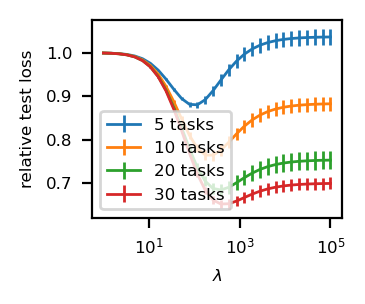

In [83]:
# plot results from multiple runs
batch_names = [
    '5tasks_TS1_R0_D0_1L_fW0',
    '10tasks_TS1_R0_D0_1L_fW0',
    '20tasks_TS1_R0_D0_1L_fW0',
    '30tasks_TS1_R0_D0_1L_fW0_0cycles'
]
key = '500'

def get_relative_test_loss(all_test_loss):
    if len(all_test_loss[key].shape) == 4:
        all_test_loss[key] = all_test_loss[key][:, :, :, -1]
    relative_loss = np.zeros_like(all_test_loss[key])

    for i in range(len(all_test_loss[key])):
        for j in range(all_test_loss[key].shape[2]):
            relative_loss[i, :, j] = all_test_loss[key][i, :, j] / all_test_loss[key][i, 0, j]
    return relative_loss[:, :, -1]

plt.figure()
lamb_values = 10 ** np.linspace(0, 5, 30)
for _bn in batch_names:
    _organizer = ClusterResultOrganizer(local_path, batch_name=_bn)
    _organizer.load_all()
    _all_test_loss = _organizer.organize_results('test loss', 'P')
    print(_all_test_loss.keys())
    _relative_test_loss = get_relative_test_loss(_all_test_loss)
    plt.errorbar(lamb_values, _relative_test_loss.mean(0),
                 _relative_test_loss.std(0) / np.sqrt(_relative_test_loss.shape[0]),
                 label=str(_organizer.args.n_tasks) + ' tasks')
plt.xscale('log')

# plt.grid()
plt.xlabel('$\lambda$')
plt.ylabel('relative test loss')
plt.legend()
plt.tight_layout()

plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')